# import

In [25]:
import sys
sys.path.append('..')
import numpy as np
from collections import defaultdict
from StatTools.generators.ndfnoise_generator import ndfnoise
from StatTools.visualization import plot_ff
from StatTools.analysis.dfa import DFA, dfa, dfa_worker
from StatTools.analysis.utils import(
    analyse_zero_cross_ff,
    analyse_cross_ff_linregress,
    ff_params,
    var_estimation
) 
from scipy.stats import linregress
from synth import postprocess_collisions, gen_traj, draw_ants_with_direction, draw_traj
from joblib import Parallel, delayed, cpu_count
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle
import pandas as pd

# collision model demo

In [ ]:
ants_num = 1000
config = {
    "frame_num": 900,
    "frame_shape": (500, 500),
    "margin": -200,
    "hurst_move": 1.2,
    "hurst_species": 0.5,
    "ants_num": ants_num,
    "start_point": None
        }
trajectories = gen_traj(**config)

In [ ]:
traj_fixed = postprocess_collisions(
    trajectories,
    radii=3.0,
    max_iter=8,
    substeps=1,
    seed=42,
)

In [ ]:
draw_traj(trajectories=traj_fixed, 
          frame_shape=config["frame_shape"],
          ants_num=ants_num,
          palette='inferno')

draw_traj(trajectories=trajectories, 
          frame_shape=config["frame_shape"],
          ants_num=ants_num,
          palette='inferno')


In [ ]:
draw_ants_with_direction(trajectories=traj_fixed,
                        #  output_path=f'../data/artifacts/{ants_num}_demo_collision.mp4',
                        output_path=None,
                         frame_num=config["frame_num"],
                         ants_num=config["ants_num"],
                         frame_shape=config["frame_shape"],
                         ant_length = 2,
                         ant_width = 2,
                         smooth_window=4,
                         imshow=True)

# solid pipe H vs density with collisions

In [28]:
np.random.seed(42)
ants_nums = np.array([int(np.exp(step)) for step in np.arange(np.log(1000), np.log(10000), 0.3)])
density_dict_collision = {}
density_dict_no_collision = {}
s_min = 6
s_values = np.array([int(np.exp(step)) for step in np.arange(np.log(s_min), np.log(2000/4), 0.5)])
hurst_move = 1.2

In [30]:

for ants_num in ants_nums:
    config = {
        "frame_num": 2000,
        "frame_shape": (500, 500),
        "margin": 0,
        "hurst_move": 1.2,
        "hurst_species": 0.5,
        "ants_num": ants_num,
        "start_point": None
            }
    trajectories = gen_traj(**config)
    traj_fixed = postprocess_collisions(
        trajectories,
        radii=4.0,
        max_iter=8,
        substeps=1,
        seed=42,
    )

    fGn_fixed = np.diff(traj_fixed, axis=0)
    fGn_fixed = fGn_fixed.reshape(fGn_fixed.shape[0], -1)

    def worker(series, n_integral, s_values):
        _, F2_s = dfa(dataset=series,
                    degree=2,
                    s_values=s_values,
                    processes=1,
                    n_integral=n_integral)
        return F2_s

    # corrected trajs
    F2_s_field_result = []

    tasks = [fGn_fixed[:, j] for j in range(fGn_fixed.shape[1])]
    n_tasks = len(tasks)

    results = Parallel(n_jobs=12, backend='loky', verbose=0)(
        delayed(worker)(task, 1, s_values) for task in tqdm(tasks, desc=f'DFA calc', unit='series')
    )


    F2_s = np.array(results)
    F_s = np.sqrt(F2_s)
    density_dict_collision[ants_num] = F_s

    # source trajs
    F2_s_field_result = []

    tasks = [fGn_fixed[:, j] for j in range(fGn_fixed.shape[1])]
    n_tasks = len(tasks)

    results = Parallel(n_jobs=12, backend='loky', verbose=0)(
        delayed(worker)(task, 1, s_values) for task in tqdm(tasks, desc=f'DFA calc', unit='series')
    )


    F2_s = np.array(results)
    F_s = np.sqrt(F2_s)
    density_dict_no_collision[ants_num] = F_s

density_dict_no_collision['s_values'] = s_values
density_dict_collision['s_values'] = s_values  

with open('../data/artifacts/density_collision_ff_eval.pkl', 'wb') as f:
    pickle.dump(density_dict_collision, f)

with open('../data/artifacts/density_no_collision_ff_eval.pkl', 'wb') as f:
    pickle.dump(density_dict_no_collision, f)

/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:51: RuntimeWarning: divide by zero encountered in power
  S *= np.abs(f.reshape(reshape)) ** (-(hurst[i] - 0.5))
DFA calc: 100%|██████████| 16332/16332 [00:19<00:00, 818.10series/s]


# plot

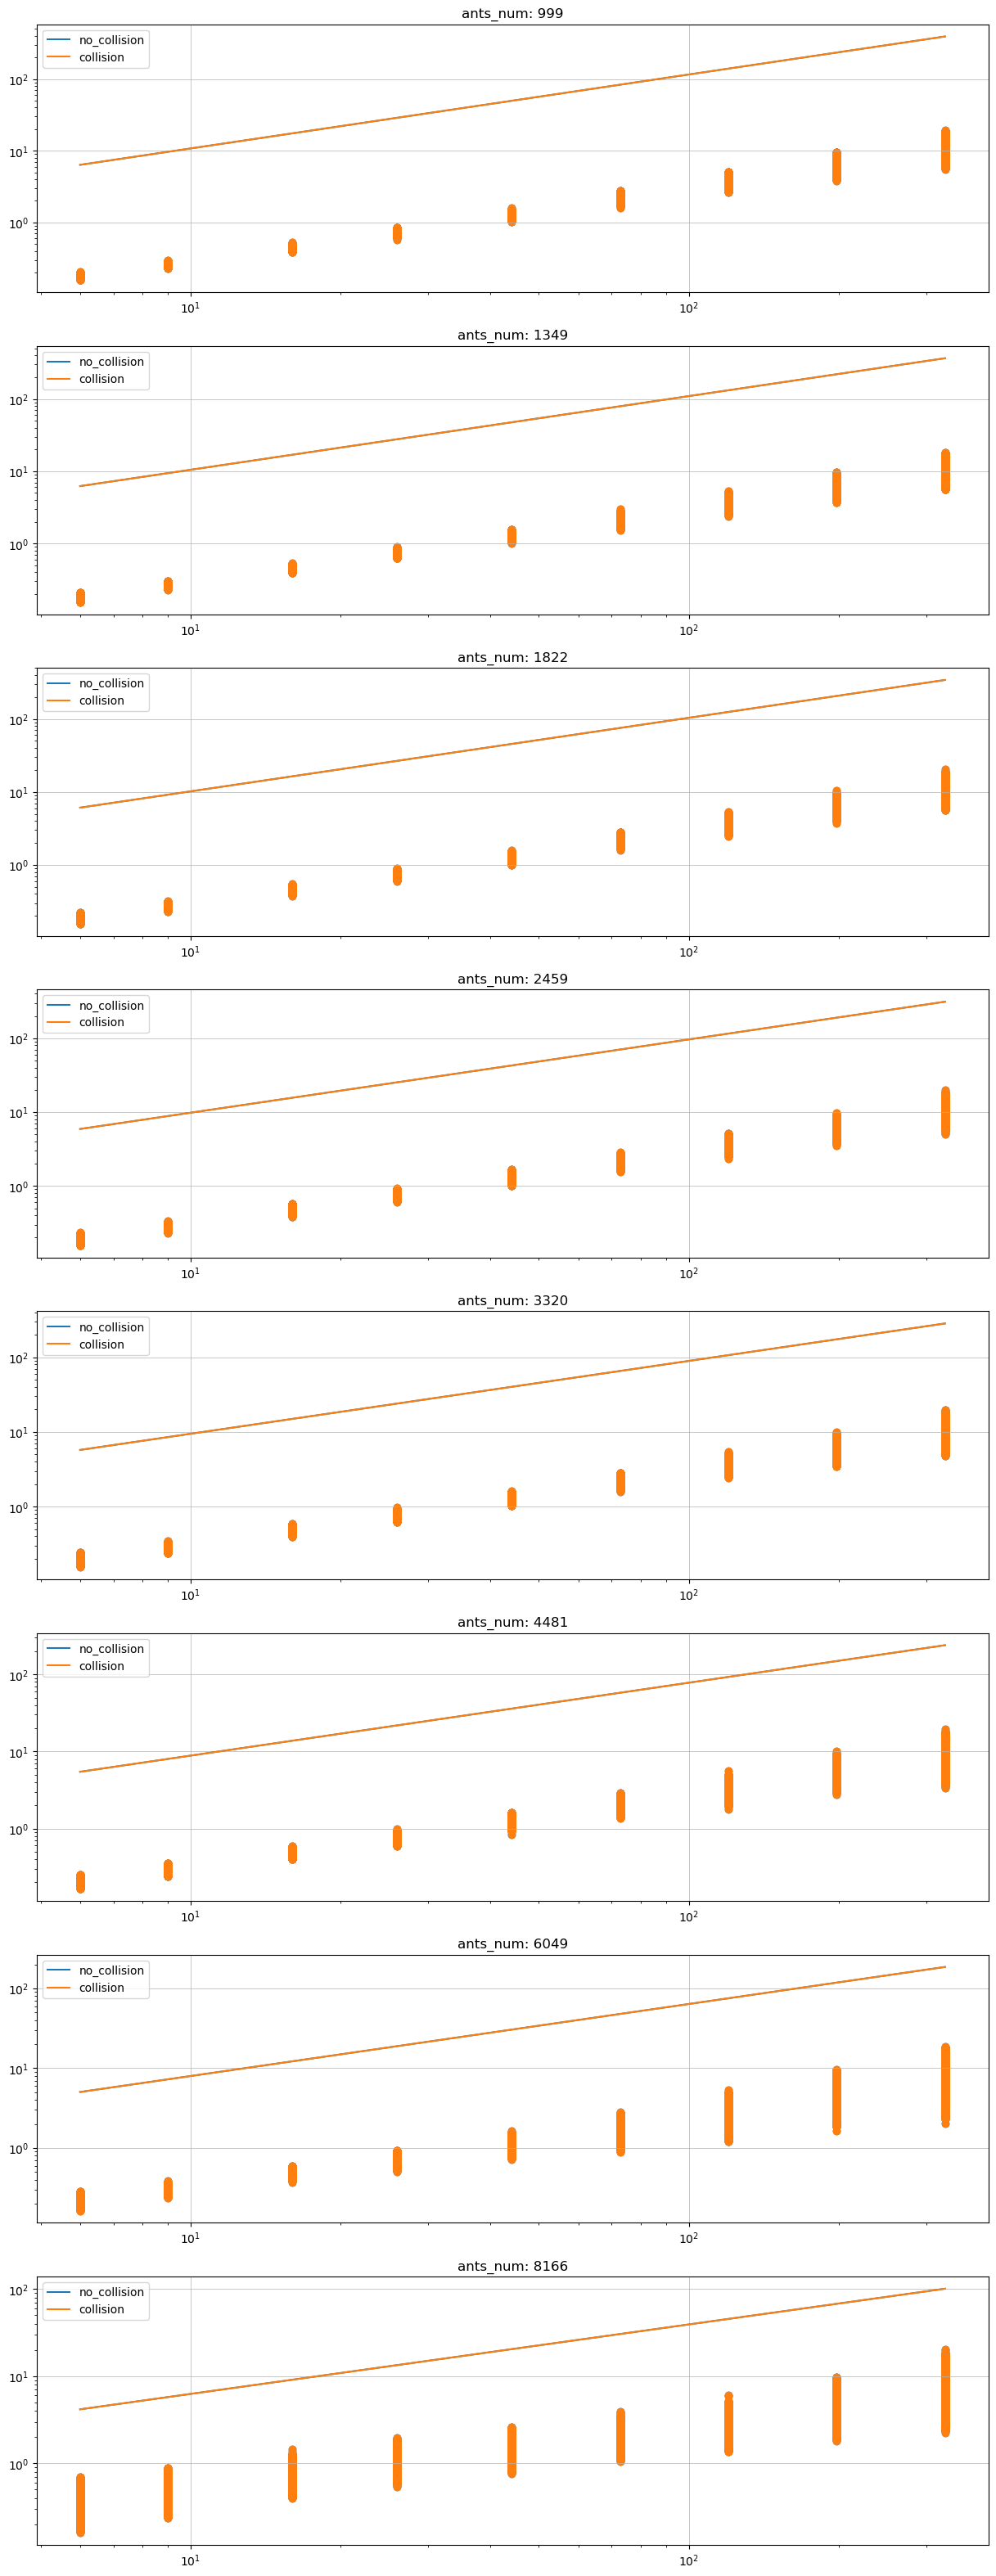

In [58]:
def remove_intercept(x ,y):
    linreg = linregress(x, y)
    return y - linreg.intercept

def plot_ff_slopes(
        hs: np.ndarray | None,
        S: np.ndarray,
        ff_parameter: ff_params,
        residuals: np.ndarray | None = None,
        ax=None,
        label:str = None,
        title:str = None,
        linestyle=None,
        color = None
        ):

    hurst = ff_parameter.slopes[0].value
    b = ff_parameter.intercept.value
    if hs is not None:
        hs_array = np.asarray(hs)
        S_new = np.repeat(S[:, np.newaxis], hs_array.shape[0], 1).T
        ax.scatter(S_new, hs_array)
    fit_func = 10 ** (hurst * np.log10(S) + b)
    ax.plot(S, fit_func, label=label, linestyle=linestyle, color=color)
    ax.set_xscale("log")
    ax.set_yscale("log")
    
    if title:
        ax.set_title(title)
    
    ax.grid(which='both', linewidth=0.5)
    return ax


density_dict_collision  = pd.read_pickle('../data/artifacts/density_collision_ff_eval.pkl')
density_dict_no_collision  = pd.read_pickle('../data/artifacts/density_no_collision_ff_eval.pkl')

fig, axes = plt.subplots(figsize=(15, 5*len(ants_nums)), nrows=len(ants_nums))
axes = axes.flatten()
for ants_num, ax in zip(ants_nums, axes):

    F_s_collision = density_dict_collision[ants_num]
    ff_params_collision, _ = analyse_zero_cross_ff(F_s_collision, s_values)

    F_s_no_collision = density_dict_no_collision[ants_num]
    ff_params_no_collision, _ = analyse_zero_cross_ff(F_s_no_collision, s_values)

    ff_params_collision.intercept = var_estimation(0.0, 0.0)
    ff_params_no_collision.intercept = var_estimation(0.0, 0.0)
    set_h = ff_params(intercept=var_estimation(0.0, 0.0), slopes=[var_estimation(hurst_move, 0.0)], cross=None, ridigity=None)

    # plot_ff_slopes(
    #         None,
    #         s_values,
    #         ff_parameter=set_h,
    #         residuals=None,
    #         ax=ax,
    #         label = f'source fGn', 
    #         linestyle='--')
    
    plot_ff_slopes(
            F_s_no_collision,
            s_values,
            ff_parameter=ff_params_no_collision,
            residuals=None,
            ax=ax,
            label = f'no_collision', 
            linestyle='-')
    
    plot_ff_slopes(
            F_s_collision,
            s_values,
            ff_parameter=ff_params_collision,
            residuals=None,
            ax=ax,
            label = f'collision', 
            title = f'ants_num: {ants_num}',
            linestyle='-')
    
    ax.legend()
    ax.grid(which='minor')